# Heart Disease Classification Using Machine Learning

Rahul Kumar Jena. Original academic submission: Team 8, AIT 614. The repository contains revised experiments and labels historical material separately.

Saved outputs display the tested analysis results. Change REBUILD to True to rerun the shared pipeline.

In [1]:
from pathlib import Path
import json, runpy
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
if not (ROOT/"scripts/run_analysis.py").exists():
    raise FileNotFoundError("Launch this notebook from the repository root")
REBUILD=False
if REBUILD:
    runpy.run_path(str(ROOT/"scripts/run_analysis.py"),run_name="__main__")
summary=json.loads((ROOT/"results/experiment_summary.json").read_text())
print(json.dumps(summary,indent=2))

{
  "source_sha256": "574f2fa2b43012fa25fca4fcdb36bd7c6bccdd0af4242f6c0e4c8633c5a072ae",
  "records": 920,
  "columns": 16,
  "target_counts": {
    "0": 411,
    "1": 509
  },
  "train_records": 736,
  "holdout_records": 184,
  "selected_model": "SVM",
  "selection_metric": "training five-fold ROC-AUC",
  "random_seed": 42,
  "rf_search_candidates": 20,
  "rf_best_params": {
    "model__n_estimators": 100,
    "model__min_samples_split": 5,
    "model__min_samples_leaf": 2,
    "model__max_features": "sqrt",
    "model__max_depth": 5
  },
  "predictors": [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
  ],
  "excluded_predictors": [
    "id",
    "dataset",
    "num"
  ],
  "warnings": [],
  "execution_notes": [
    "Tuning and model selection share CV folds; CV is not nested and tuned CV scores may be optimistic.",
    "Holdout metrics are from one fixed pooled split at

## Training cross-validation

In [2]:
display(pd.read_csv(ROOT/"results/tables/cross_validation_metrics.csv"))

,model,cv_roc_auc,cv_roc_auc_std,cv_average_precision,cv_average_precision_std,cv_accuracy,cv_accuracy_std,cv_f1,cv_f1_std,cv_recall,cv_recall_std
0,SVM,0.890792,0.025566,0.890176,0.032323,0.822017,0.036718,0.844121,0.027418,0.867209,0.034462
1,TunedRandomForest,0.886308,0.023944,0.885030,0.026211,0.803015,0.037989,0.826297,0.026458,0.842698,0.022466
2,LogisticRegression,0.885206,0.024499,0.898484,0.022182,0.811197,0.028457,0.832351,0.019686,0.845107,0.033828
3,RandomForest,0.877087,0.027932,0.868129,0.041120,0.803034,0.031496,0.827165,0.018090,0.847546,0.024830
4,NeuralNetworkMLP,0.713105,0.177647,0.747787,0.137689,0.674214,0.128359,0.592444,0.308273,0.536314,0.294871
5,DecisionTree,0.707432,0.074524,0.695559,0.059649,0.710544,0.070372,0.737940,0.056998,0.734538,0.066040


## Pooled holdout results

In [3]:
display(pd.read_csv(ROOT/"results/tables/holdout_metrics.csv"))

,model,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,tn,fp,fn,tp
0,LogisticRegression,0.842391,0.841121,0.882353,0.792683,0.861244,0.903515,0.909983,65,17,12,90
1,DecisionTree,0.755435,0.771429,0.794118,0.707317,0.782609,0.750717,0.726735,58,24,21,81
2,RandomForest,0.853261,0.850467,0.892157,0.804878,0.870813,0.919955,0.931071,66,16,11,91
3,SVM,0.842391,0.817391,0.921569,0.743902,0.866359,0.916667,0.924002,61,21,8,94
4,NeuralNetworkMLP,0.771739,0.840909,0.725490,0.829268,0.778947,0.815340,0.815861,68,14,28,74
5,TunedRandomForest,0.853261,0.850467,0.892157,0.804878,0.870813,0.927905,0.942446,66,16,11,91


## Preprocessing sensitivity

In [4]:
display(pd.read_csv(ROOT/"results/tables/preprocessing_comparison.csv"))

,variant,cv_roc_auc,cv_average_precision,cv_accuracy,cv_f1,cv_recall
0,median_standard,0.885206,0.898484,0.811197,0.832351,0.845107
1,mean_standard,0.889199,0.904727,0.811188,0.831942,0.842608
2,median_minmax,0.884571,0.892352,0.812539,0.833264,0.845017
3,omit_heavily_missing,0.873444,0.882862,0.789437,0.812773,0.822975
4,zero_bp_chol_as_missing,0.879720,0.888746,0.807079,0.828598,0.844926


## Exploratory site transfer

In [5]:
display(pd.read_csv(ROOT/"results/tables/site_transfer_exploratory.csv"))

,model,site,train_records,evaluation_records,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,tn,fp,fn,tp
0,SVM,Cleveland,616,304,0.723684,0.639594,0.906475,0.569697,0.750000,0.847787,0.818326,94,71,13,126
1,SVM,Hungary,627,293,0.825939,0.723577,0.839623,0.818182,0.777293,0.886111,0.826007,153,34,17,89
2,SVM,Switzerland,797,123,0.878049,0.946429,0.921739,0.250000,0.933921,0.757609,0.976842,2,6,9,106
3,SVM,VA Long Beach,720,200,0.680000,0.824427,0.724832,0.549020,0.771429,0.676076,0.840405,28,23,41,108


## Interpretability

In [6]:
display(pd.read_csv(ROOT/"results/tables/permutation_importance.csv"))

,feature,mean_auc_decrease,std
0,cp,0.046832,0.010600
1,chol,0.042420,0.011181
2,oldpeak,0.027367,0.008815
3,sex,0.017826,0.006909
4,exang,0.016714,0.005702
5,ca,0.010820,0.004831
6,thalch,0.008393,0.008060
7,fbs,0.007353,0.002547
8,age,0.006636,0.004682
9,thal,0.006636,0.004183


## Historical values: different evaluation workflow

In [7]:
display(pd.read_csv(ROOT/"results/tables/historical_metrics.csv"))

,model,accuracy,f1,recall,roc_auc
0,LogisticRegression,0.8152,0.8396,0.8165,0.8379
1,DecisionTree,0.7772,0.7960,0.7339,0.7870
2,RandomForest,0.8533,0.8720,0.8440,0.9109
3,SVM,0.8261,0.8505,0.8349,0.8232
4,NeuralNetworkTensorFlow,0.8098,0.8372,0.8257,0.8334
5,TunedRandomForest,0.8587,0.8796,0.8716,0.9118


## Visualizations

class_distribution.png
confusion_matrices.png
feature_importance.png
missing_values.png
model_comparison.png
precision_recall_curves.png
preprocessing_comparison.png
roc_curves.png
site_transfer.png


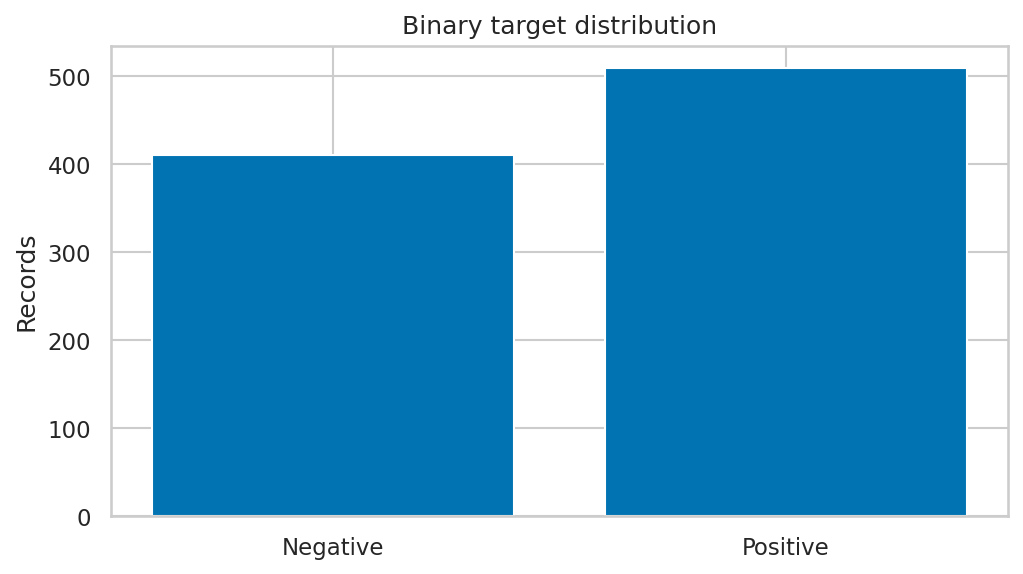

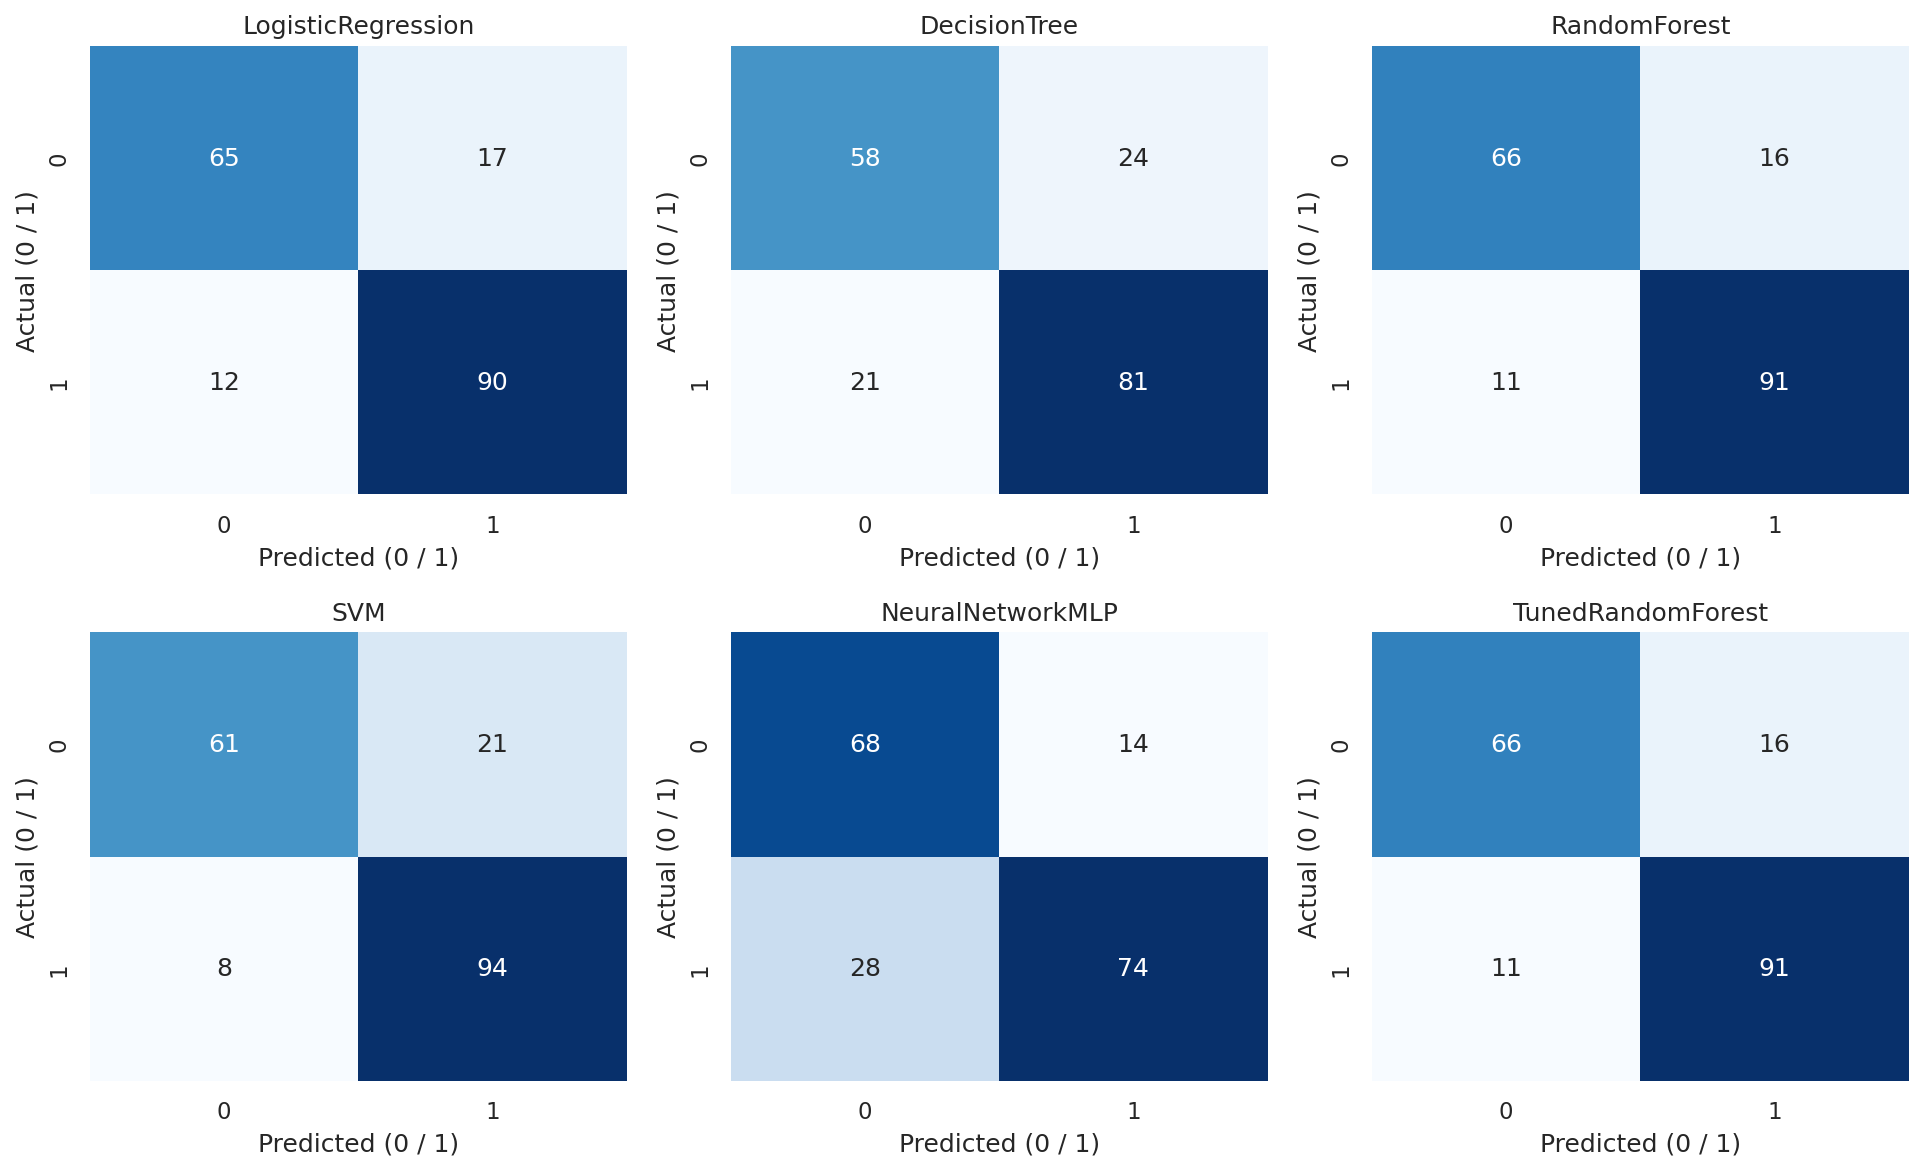

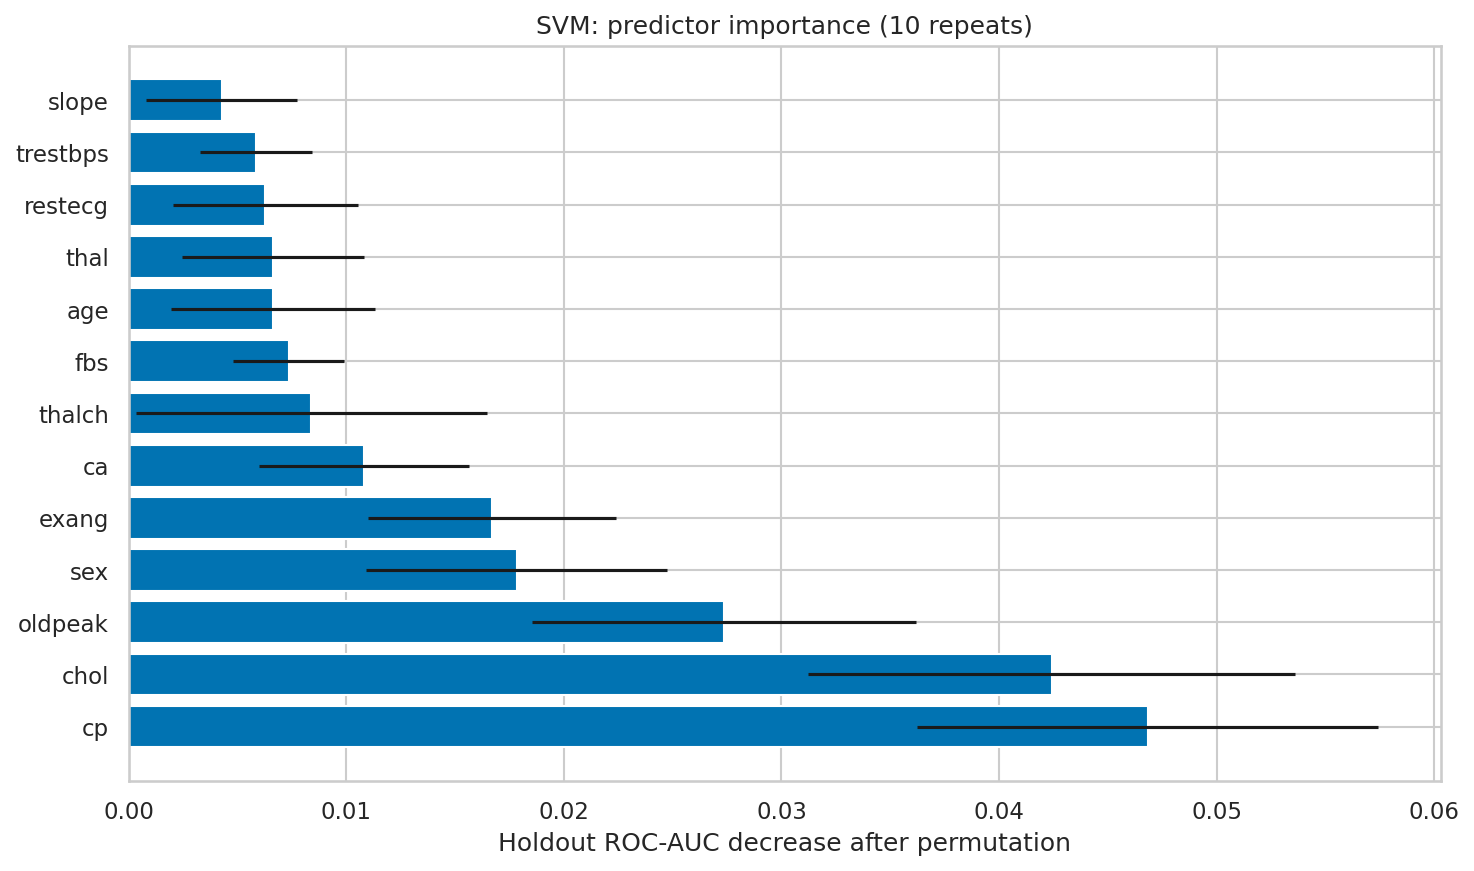

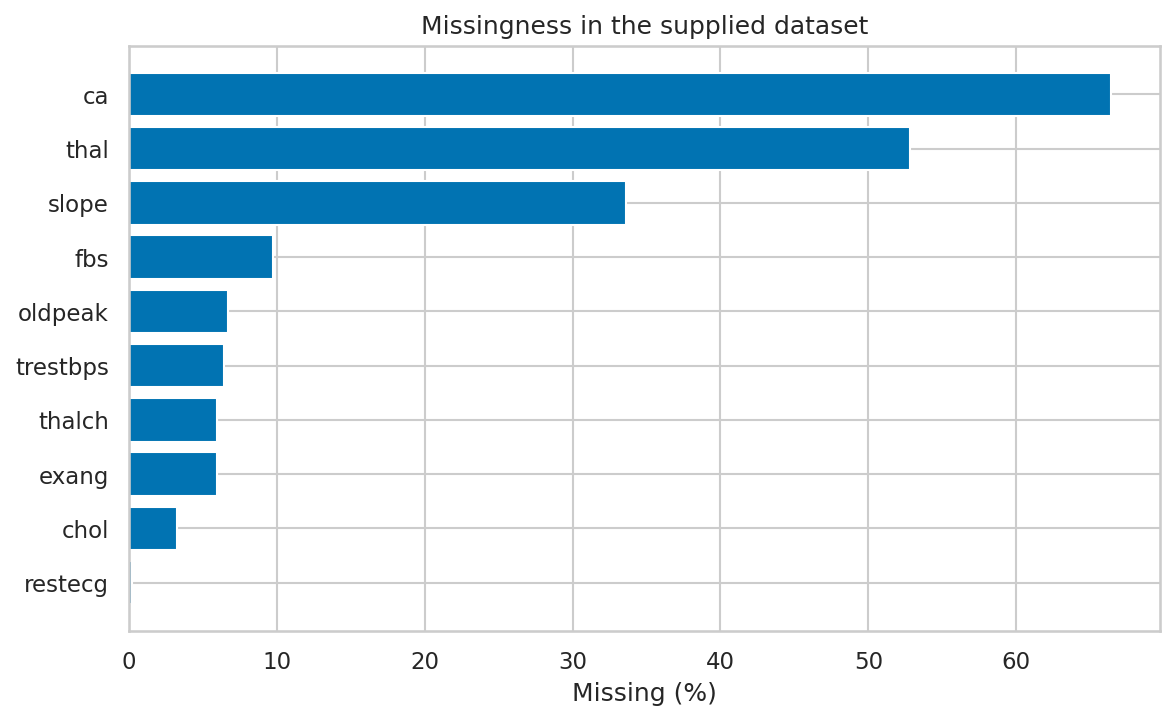

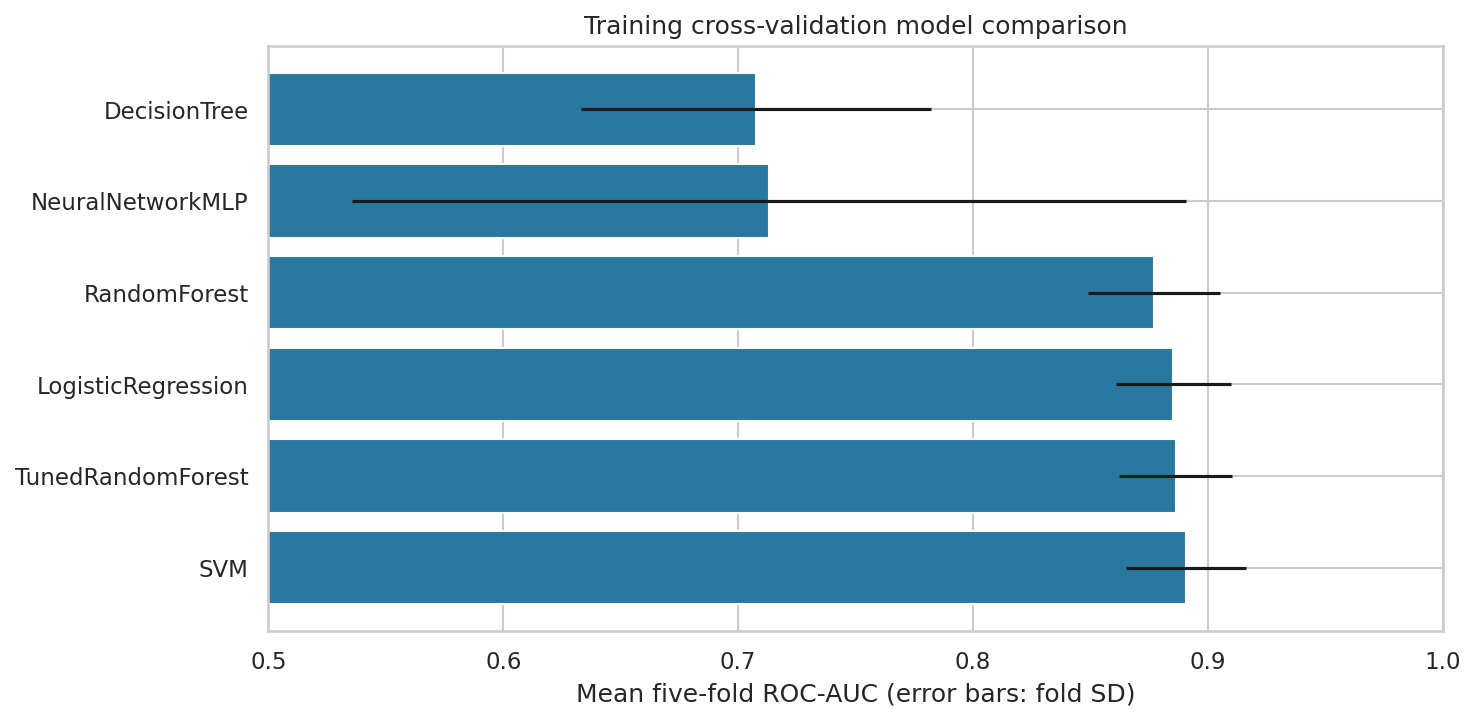

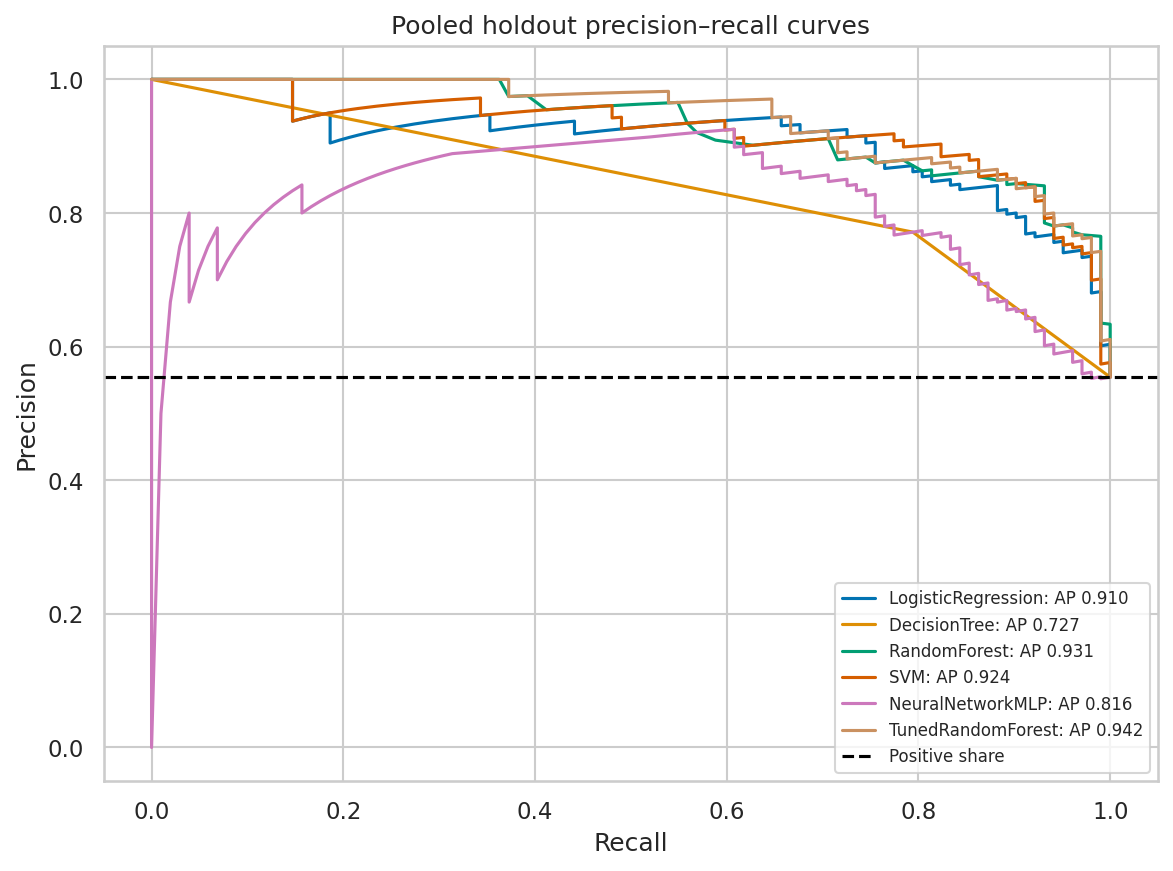

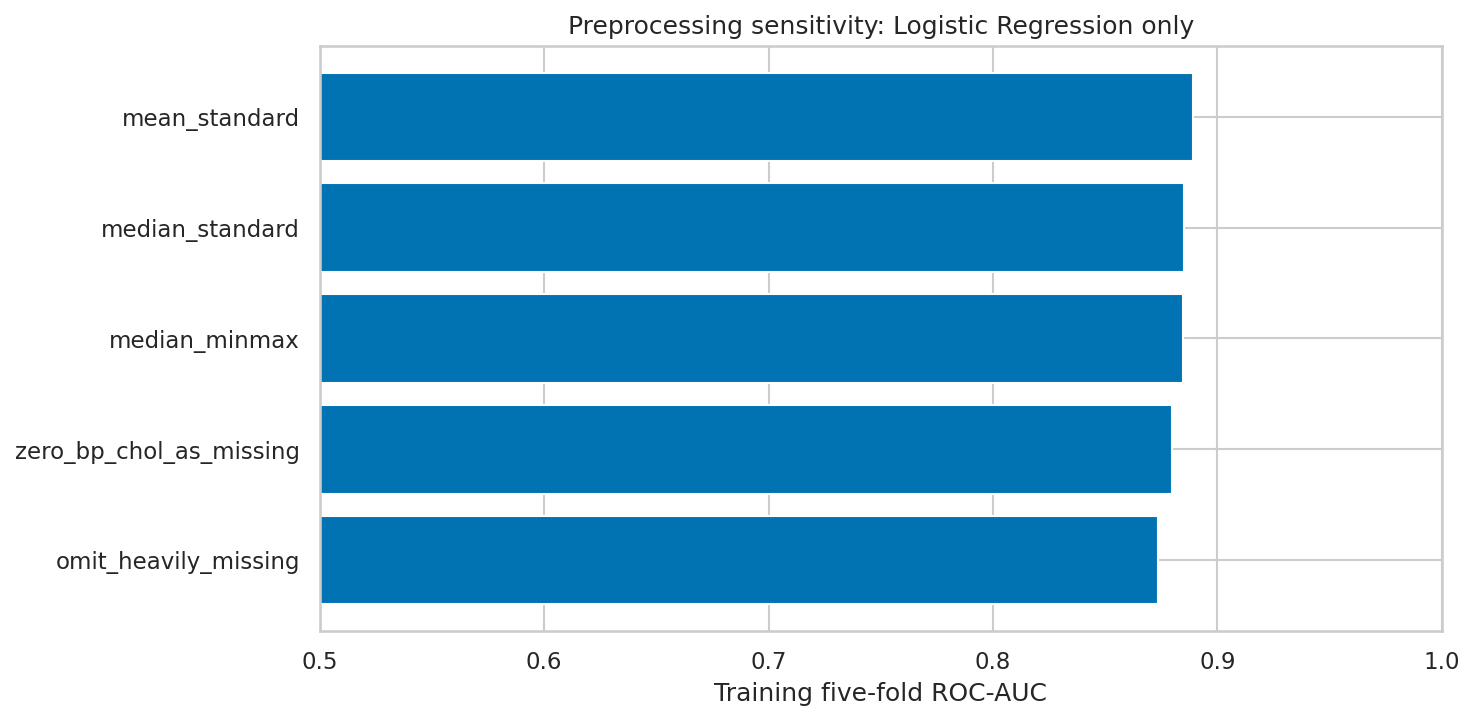

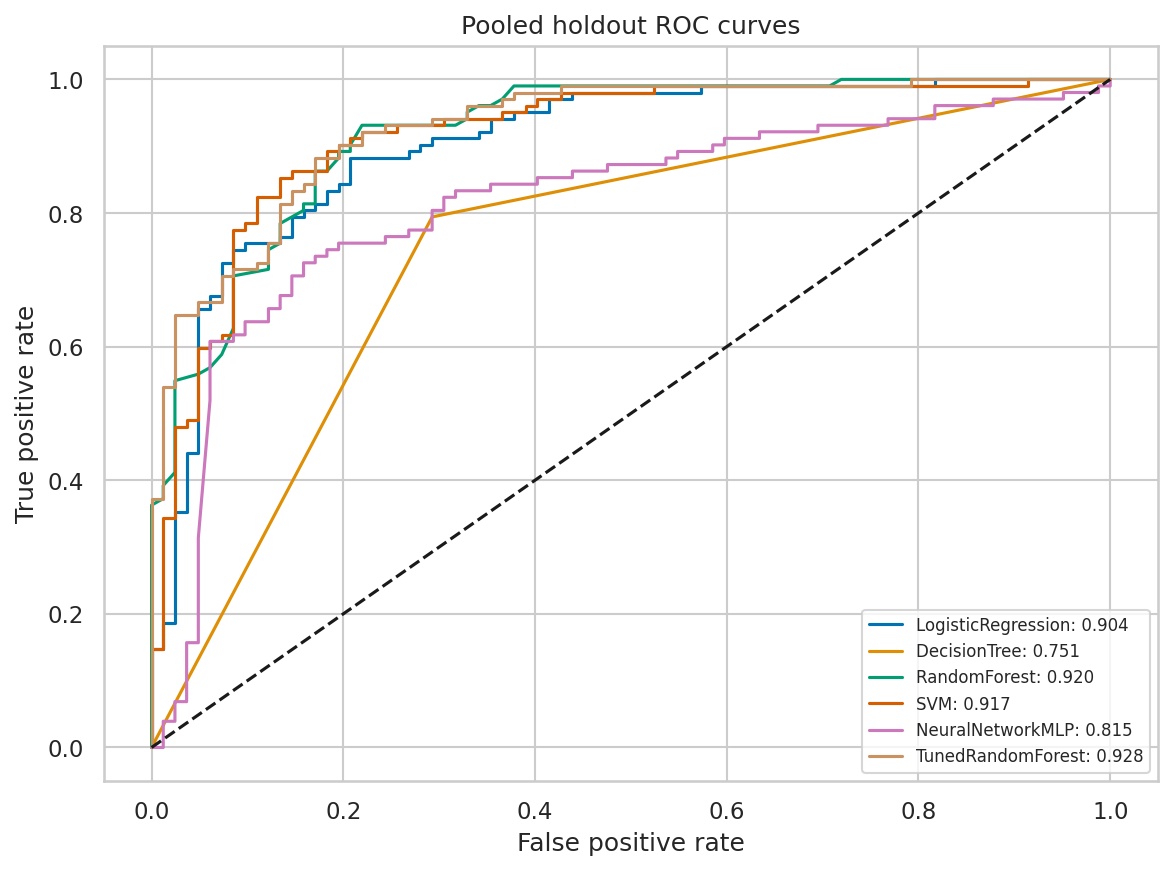

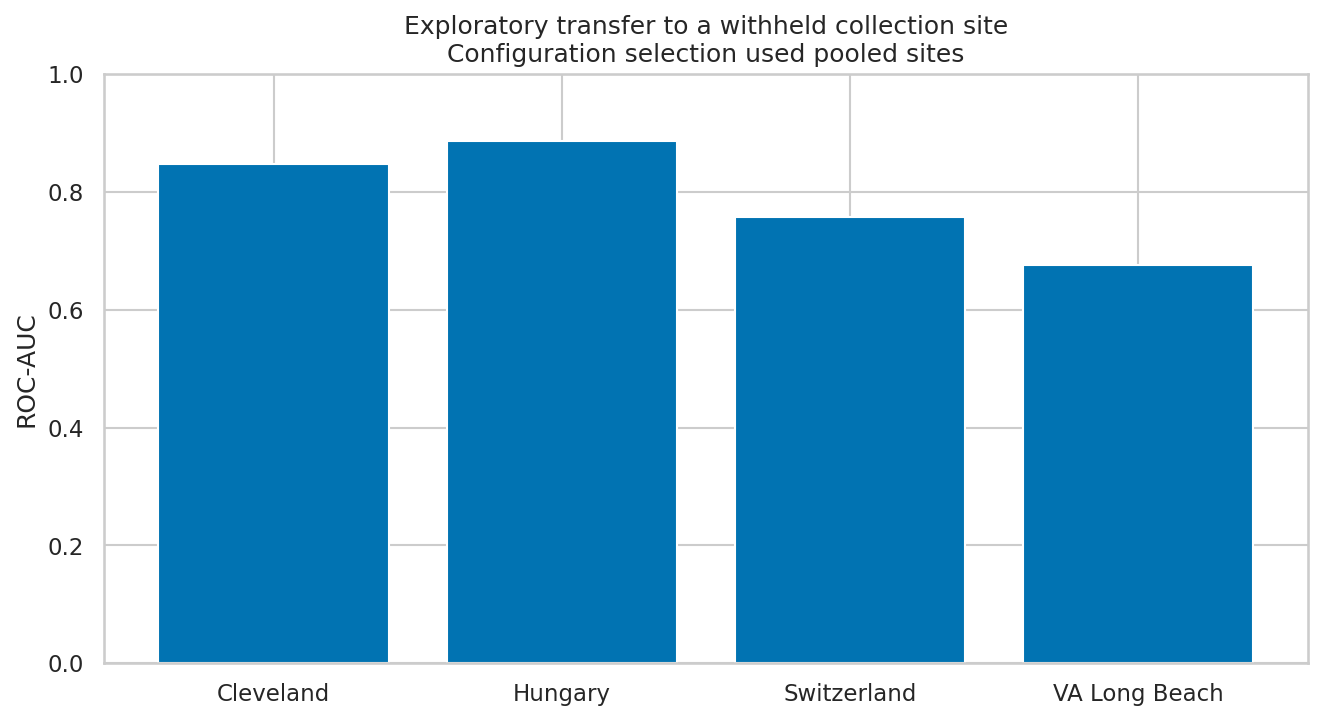

In [8]:
for chart in sorted((ROOT/"results/plots").glob("*.png")):
    print(chart.name)
    display(Image(filename=str(chart)))

In [9]:
runpy.run_path(str(ROOT/"scripts/verify.py"),run_name="__main__")

Verified source checksum, split separation, all six models' holdout metrics, fold-only imputation, and nine PNG charts.
Out[0]: 
{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/workspace/scratch/33948fc581af/heart-disease-classification/scripts/verify.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImpo

## Conclusion

SVM leads by training CV ROC-AUC, while tuned Random Forest has higher pooled holdout ROC-AUC. Site transfer varies substantially. The results describe one historical dataset and do not validate clinical deployment. Full answers to five research questions are in README.md.